In [3]:
import numpy as np
import pandas as pd
import glob
from numba import guvectorize
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import os
from datetime import datetime, timezone
import re
import json

from dbetto import Props
from legendmeta import LegendMetadata
from lgdo import lh5
import lgdo
from pygama.pargen.dsp_optimize import run_one_dsp
import lgdo.types as lgdo_types
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib.patches as mpatches
from pygama import hit

import itertools
from tqdm import tqdm

In [4]:
chn = "ch1118402"
period    = 'p08'
run       = 'r008'
data_path = '/global/cfs/cdirs/m2676/data/lngs/l200/public/prodenv/prod-blind/ref/latest'

In [3]:
from lgdo.types.table import Table
from lgdo.types.array import Array
from lgdo.types.arrayofequalsizedarrays import ArrayOfEqualSizedArrays
from lgdo.types.vectorofvectors import VectorOfVectors
from lgdo.types.waveformtable import WaveformTable

def _copy_attrs(col):
    """Copy attrs without the auto-generated datatype field."""
    return {k: v for k, v in col.attrs.items() if k != "datatype"}


def _index_column(col, indices):
    """Recursively index a single LGDO column by an array of integer indices."""

    if isinstance(col, WaveformTable):
        new_values = _index_column(col.values, indices)
        return WaveformTable(
            t0=col.t0.nda[indices],
            t0_units=col.attrs.get("t0_units", col.t0.attrs.get("units", None)),
            dt=col.dt.nda[indices],
            dt_units=col.attrs.get("dt_units", col.dt.attrs.get("units", None)),
            values=new_values,
            values_units=col.values.attrs.get("units", None),
        )

    elif isinstance(col, VectorOfVectors):
        rows = [col[int(i)] for i in indices]
        flattened = np.concatenate(rows) if rows else np.array([], dtype=col.flattened_data.nda.dtype)
        cum_lengths = np.cumsum([len(r) for r in rows]).astype(col.cumulative_length.nda.dtype)
        return VectorOfVectors(
            flattened_data=Array(flattened),
            cumulative_length=Array(cum_lengths),
            attrs=_copy_attrs(col),
        )

    elif isinstance(col, ArrayOfEqualSizedArrays):
        return ArrayOfEqualSizedArrays(nda=col.nda[indices], attrs=_copy_attrs(col))

    elif isinstance(col, Array):
        return Array(nda=col.nda[indices], attrs=_copy_attrs(col))

    else:
        raise TypeError(f"Unhandled LGDO column type: {type(col).__name__}")


def extend_table(table: Table, target_length: int) -> Table:
    current_length = table.size

    if target_length < current_length:
        raise ValueError(
            f"target_length ({target_length}) must be >= current length ({current_length})"
        )

    indices = np.arange(target_length) % current_length

    return Table(col_dict={
        col_name: _index_column(table[col_name], indices)
        for col_name in table.keys()
    })

In [3]:
config = Props.read_from(f"{data_path}/config.json", subst_pathvar=True)["setups"]["l200"]["paths"]

In [5]:
fft_path = f'{config['tier_raw']}/fft/p08/r008'
fft_files = sorted(glob.glob(f'{fft_path}/*.lh5'))
raw_table = lh5.read(f"{chn}/raw", fft_files)

In [6]:
sig_file = np.load('../Injector/output/exponential_signals.npz')
inj_p = sig_file["inj_p"]
inj_w = sig_file["inj_w"]

In [7]:
sampling_set = pd.read_pickle("../Injector/output/exponential_signals_pars.pkl").reset_index(drop=True)

In [8]:
sig_table = extend_table(raw_table, target_length=len(inj_p))

In [9]:
inj_p_lgdo = lgdo.ArrayOfEqualSizedArrays(inj_p.shape, inj_p)
inj_w_lgdo = lgdo.ArrayOfEqualSizedArrays(inj_w.shape, inj_w)

sig_table.waveform_presummed.remove_column("values")
sig_table.waveform_presummed.add_column("values", inj_p_lgdo)

sig_table.waveform_windowed.remove_column("values")
sig_table.waveform_windowed.add_column("values", inj_w_lgdo)

In [5]:
dsp_proc_chain

{'outputs': ['baseline',
  'timestamp',
  'daqenergy',
  't_sat_lo',
  't_sat_hi',
  'tp_min',
  'tp_max',
  'wf_min',
  'wf_max',
  't_discharge',
  'tp_min_win',
  'tp_max_win',
  'wf_min_win',
  'wf_max_win',
  'wf_mean',
  'wf_std',
  'wf_slope',
  'wf_intercept',
  'wf_slope_diff',
  'wf_slope_rms',
  'bl_mean',
  'bl_std',
  'bl_slope',
  'bl_intercept',
  'bl_slope_diff',
  'bl_slope_rms',
  'tail_pars',
  'tail_slope',
  'tail_diff',
  'tail_rms',
  'pz_mean',
  'pz_std',
  'pz_slope',
  'pz_intercept',
  'pz_slope_diff',
  'pz_slope_rms',
  'baselineEmax',
  'tailEmax',
  'trapTmax',
  'trapTmin',
  'trapTftp',
  'trapSmax',
  'trapEmax',
  'trapEftp',
  'cuspEmax',
  'cuspEmin',
  'cuspEftp',
  'zacEmax',
  'zacEftp',
  'baselineEmax',
  'tailEmax',
  'tp_trapTmax',
  'tp_trapTmin',
  'tp_0_est',
  'tp_0_atrap',
  'tp_01',
  'tp_10',
  'tp_20',
  'tp_50',
  'tp_80',
  'tp_90',
  'tp_95',
  'tp_99',
  'tp_100',
  'A_max',
  'tp_aoe_max',
  'QDrift',
  'dt_eff',
  'tp_80_lq',
 

In [4]:
dsp_proc_chain = glob.glob(f'{config["config"]}/tier_dsp/*ICPC-dsp_proc_chain.json')[0]

with open(dsp_proc_chain, "r") as file:
    dsp_proc_chain = json.load(file)

dsp_proc_chain["outputs"] = [
    x for x in dsp_proc_chain["outputs"]
    if not ("dplms" in x.lower() or "svm" in x.lower())
]

par_psp_path = glob.glob(f'{config['par_psp']}/cal/{period}/{run}/*json')[0]
with open(par_psp_path, "r") as file:
    par_psp = json.load(file)

In [12]:
dsp_data = run_one_dsp(sig_table, dsp_proc_chain, db_dict=par_psp[chn])

Processing table : 100%|##########| 100000/100000 [03:35<00:00, 464.68 rows/s]

In [13]:
lh5.write(dsp_data, f"{chn}/dsp", "dsp_data_exp.lh5", wo_mode='of')

In [14]:
hit_config = glob.glob(f'{config["config"]}/tier_hit/*ICPC-hit_config.json')[0]

with open(hit_config, "r") as r:
    hit_config = json.load(r)

hit_par = glob.glob(f'{config['par_pht']}/cal/{period}/{run}/*.json')[0]
with open(hit_par, "r") as r:
    hit_par = json.load(r)

hit_config['operations'] = {**hit_config['operations'], **hit_par[chn]['pars']['operations']}

hit_config["outputs"] = [
    x for x in hit_config["outputs"]
    if not ("dplms" in x.lower() or "svm" in x.lower())
]

hit_config["operations"] = {
    k: v for k, v in hit_config["operations"].items()
    if not ("dplms" in k.lower() or "svm" in k.lower())
}

In [15]:
hit.build_hit(infile = 'dsp_data_exp.lh5', outfile = 'hit_data_exp.lh5', hit_config = hit_config, lh5_tables = None, lh5_tables_config = None, wo_mode='of')

In [16]:
hit_data = lh5.read(f'{chn}/hit', 'hit_data_exp.lh5').view_as('pd')

In [20]:
hit_data.columns

Index(['AoE_Classifier', 'AoE_Corrected', 'AoE_Double_Sided_Cut',
       'AoE_High_Side_Cut', 'AoE_Low_Cut', 'LQ_Classifier', 'LQ_Cut',
       'bl_pileup_cut', 'bl_pileup_cut_classifier', 'cuspEmax_cal',
       'cuspEmax_ctc_cal', 'cuspEmax_noctc_cal', 'daqenergy_cal', 'dt_eff',
       'is_discharge', 'is_downgoing_baseline', 'is_empty_candidate',
       'is_highly_positive_polarity_candidate', 'is_low_cuspEmax',
       'is_neg_energy', 'is_negative', 'is_negative_crosstalk_old',
       'is_negative_polarity_candidate', 'is_noise_burst',
       'is_not_noise_burst', 'is_positive_polarity_candidate', 'is_saturated',
       'is_surface', 'is_upgoing_baseline', 'is_valid_0vbb_old',
       'is_valid_baseline_old', 'is_valid_bl_slope',
       'is_valid_bl_slope_classifier', 'is_valid_bl_slope_rms',
       'is_valid_bl_slope_rms_classifier', 'is_valid_cal', 'is_valid_cuspEmax',
       'is_valid_cuspEmax_classifier', 'is_valid_cuspEmin',
       'is_valid_cuspEmin_classifier', 'is_valid_dteff'

In [60]:
(hit_data['is_empty_candidate']==63).sum()/len(hit_data)*100

np.float64(0.0)

In [61]:
(hit_data['is_negative_polarity_candidate']==63).sum()/len(hit_data)*100

np.float64(0.0)

In [92]:
((hit_data['is_positive_polarity_candidate']==127) | (hit_data['is_positive_polarity_candidate']==123)).sum()/len(hit_data)*100

np.float64(99.992)

In [64]:
(hit_data['is_highly_positive_polarity_candidate']==511).sum()/len(hit_data)*100

np.float64(94.528)

In [69]:
qcfail = sampling_set[hit_data['is_positive_polarity_candidate']!=127]

In [133]:
hit_data[hit_data['is_highly_positive_polarity_candidate']!=511]['is_highly_positive_polarity_candidate']

6        507
24       507
26       507
56       507
65       507
        ... 
99928    507
99930    507
99940    507
99960    507
99997    507
Name: is_highly_positive_polarity_candidate, Length: 5472, dtype: uint16

In [93]:
hit_data

,AoE_Classifier,AoE_Corrected,AoE_Double_Sided_Cut,AoE_High_Side_Cut,AoE_Low_Cut,LQ_Classifier,LQ_Cut,bl_pileup_cut,bl_pileup_cut_classifier,cuspEmax_cal,...,tail_pileup_cut,tail_pileup_cut_classifier,timestamp,tp_0_est,trapEmax_cal,trapEmax_ctc_cal,trapEmax_noctc_cal,zacEmax_cal,zacEmax_ctc_cal,zacEmax_noctc_cal
0,-0.741399,0.693589,True,True,True,-20.137139,True,True,3.027061,63.319996,...,True,-0.095605,1.700504e+09,47968.0,63.223989,63.264218,63.223989,63.223875,63.266051,63.223875
1,1.085400,1.408112,True,True,True,96.338901,False,True,-0.061519,67.277141,...,True,2.252589,1.700504e+09,48448.0,67.580115,67.642636,67.580115,67.079813,67.144860,67.079813
2,1.028150,1.362790,True,True,True,229.765815,False,True,-0.369784,70.087037,...,True,2.732553,1.700504e+09,48208.0,70.240596,70.306225,70.240596,69.815496,69.883868,69.815496
3,-1.063462,0.556573,True,True,True,16.713509,False,True,0.288473,62.942307,...,True,-0.301755,1.700504e+09,47920.0,63.161735,63.219273,63.161735,62.917928,62.978014,62.917928
4,2.691972,1.955028,True,True,True,-25.700554,True,True,0.707526,69.903967,...,True,-0.363083,1.700504e+09,48272.0,69.820866,69.825904,69.820866,69.499110,69.504367,69.499110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.300253,1.535470,True,True,True,209.146228,False,True,0.681489,63.457280,...,True,0.475445,1.700504e+09,48320.0,63.519528,63.567897,63.519528,63.331173,63.381730,63.331173
99996,0.908689,1.359500,True,True,True,137.140521,False,True,0.793864,65.111967,...,True,0.717546,1.700504e+09,48352.0,65.553840,65.610438,65.553840,64.763732,64.822341,64.763732
99997,1.718813,1.831678,True,True,True,15.814337,False,True,1.962812,57.233267,...,False,28.322473,1.700504e+09,48352.0,54.989457,54.997039,54.989457,54.191688,54.199521,54.191688
99998,-1.092012,0.578730,True,True,True,-30.124430,True,True,-0.122071,66.130377,...,True,2.620807,1.700504e+09,48240.0,67.289482,67.396165,67.289482,65.428857,65.537562,65.428857


In [82]:
tail_start = 60000-sampling_set['tp_0_est'].mode()[0]
tail_start

np.float64(11904.0)

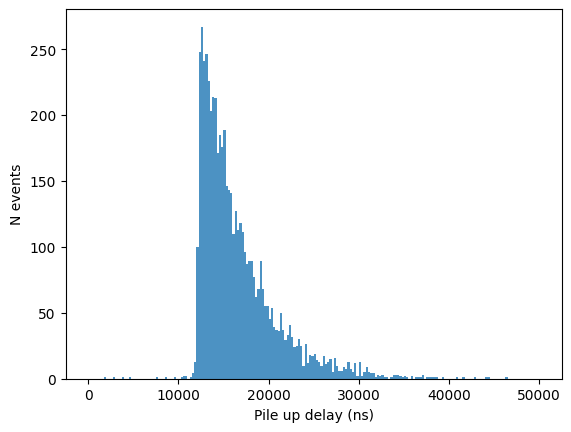

In [132]:
bins = np.linspace(0, 50000, 201)  # 200 bins
plt.hist(qcfail['exp_t0'], bins=bins, alpha=0.8)
#plt.hist(sampling_set[sampling_set['exp_t0']>tail_start]['exp_t0'], bins=bins, alpha=0.8)
plt.xlabel('Pile up delay (ns)')
plt.ylabel('N events')
plt.show()

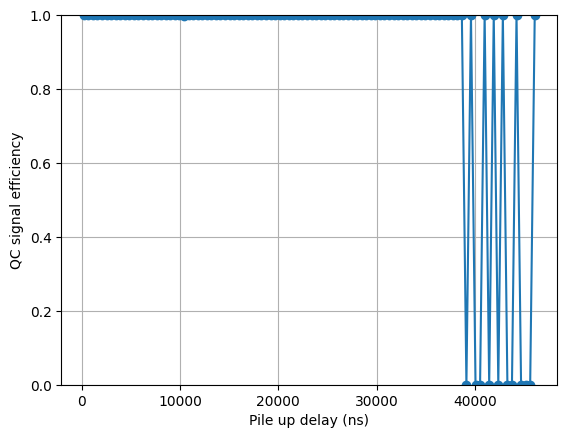

In [129]:
# define bins (same idea you used before)
bins = np.linspace(
    sampling_set['exp_t0'].min(),
    sampling_set['exp_t0'].max(),
    101
)

# precompute masks once
exp_t0 = sampling_set['exp_t0']
is_pos = (hit_data['is_positive_polarity_candidate'] == 127) | (hit_data['is_positive_polarity_candidate'] == 123)

# denominator: all events per bin
counts_total, _ = np.histogram(exp_t0, bins=bins)

# numerator: passing events per bin
counts_pass, _ = np.histogram(exp_t0[is_pos], bins=bins)

# efficiency (avoid divide-by-zero)
eff = np.divide(
    counts_pass,
    counts_total,
    out=np.zeros_like(counts_pass, dtype=float),
    where=counts_total > 0
)

# bin centers for plotting
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# plot
plt.plot(bin_centers, eff, marker='o')
plt.xlabel("Pile up delay (ns)")
plt.ylabel("QC signal efficiency")
plt.ylim(0, 1)
plt.grid(True)
plt.show()